## 1. One power spectrum, many realizations

1. No, me espero que sí puedan variar. Si 5 campos, suponiendolos aleatorios, son generados del mismo *power spectrum* $P(k)$, yo me espero que estos campos puedan variar en algunas de sus propiedades, puesto que $P(k)$ está relacionado con la varianza $\sigma$ de la distribución, pero una distribución no está totalmente definida por su $\sigma$.
2. Esperaría que su $\sigma$ y $\mu$ se conserven entre todos los campos, pensando en distribuciones gaussianas, o $\sigma$ y sus variables que dan lugar a la familia concreta de la distribución, por ejemplo.
3. Me esperaría que la amplitud máxima, mínima y la densidad de puntos puedan variar.
4. La amplitud de cada modo estará asociado a qué tan perfecto los puntos aleatorios replican la envolvente de la distribución, $N \to \infty$, así, las amplitudes podrán representar imperfecciones a pequeña escala y sus formas identificables a grandes escalas que identifican a la distribución. La fase debe star relacionado con la posición en el espacio real de la distribución: diferentes fases, diferentes posiciones en el espacio real de la estructura a grandes y pequeñas escalas, es decir, la fase estará relacionada con $\mu$.

### 1.1. Generate five realizations

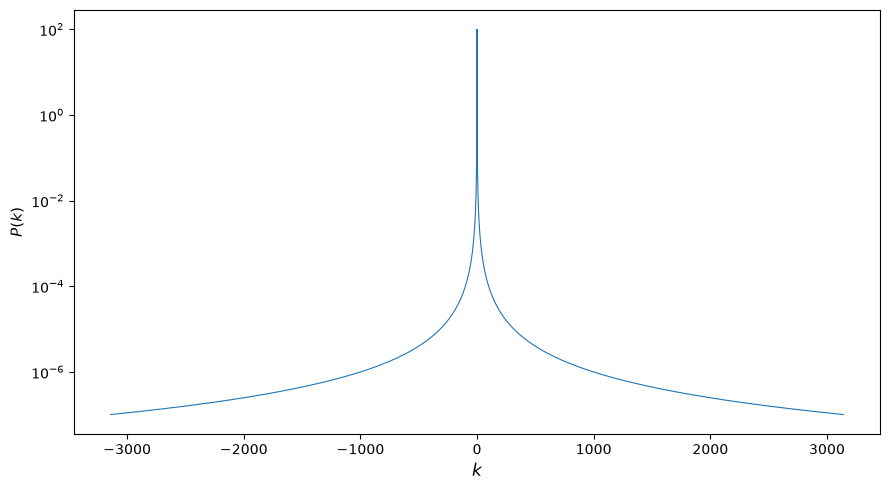

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def P(k, ep):
    n = 1
    d = (np.abs(k) + ep) ** 2
    return n / d

SEED = 42
rng = np.random.default_rng(SEED)

N = 10000 # Samples
lb, rb = 0, 10 # Bounderies

real_space = np.linspace(lb, rb, N)
dx = real_space[1] - real_space[0]

fourier_space_unshifted = 2 * np.pi * np.fft.fftfreq(N, d=dx)
fourier_space = np.fft.fftshift(fourier_space_unshifted)

Pk = P(fourier_space, ep=0.1)

plt.figure(figsize=(9, 5))
plt.plot(fourier_space, Pk, lw=0.8)
plt.yscale('log')
plt.ylabel('$P(k)$', fontsize=11)
plt.xlabel('$k$', fontsize=12)
plt.tight_layout()
plt.show()

SAbiendo que $\sigma^2 \propto P(k)$, donde $\sigma^2$ es la varianza del campo aleatorio $\delta_k$, entonces se pueden generar 5 campos aleatorios $\delta_k \sim \mathcal{N}(\mu, \sigma^2)$, con $\mu = 0$ por el teorema de Wick.

In [2]:
rng_childs = rng.spawn(5) # Childs

L = 10
delta_k = np.asarray([rng_childs[i].normal(0, np.sqrt(N ** 2 * Pk / L)) for i in range(5)])
delta_x = np.fft.ifft(np.fft.ifftshift(delta_k, axes=1), axis=1)

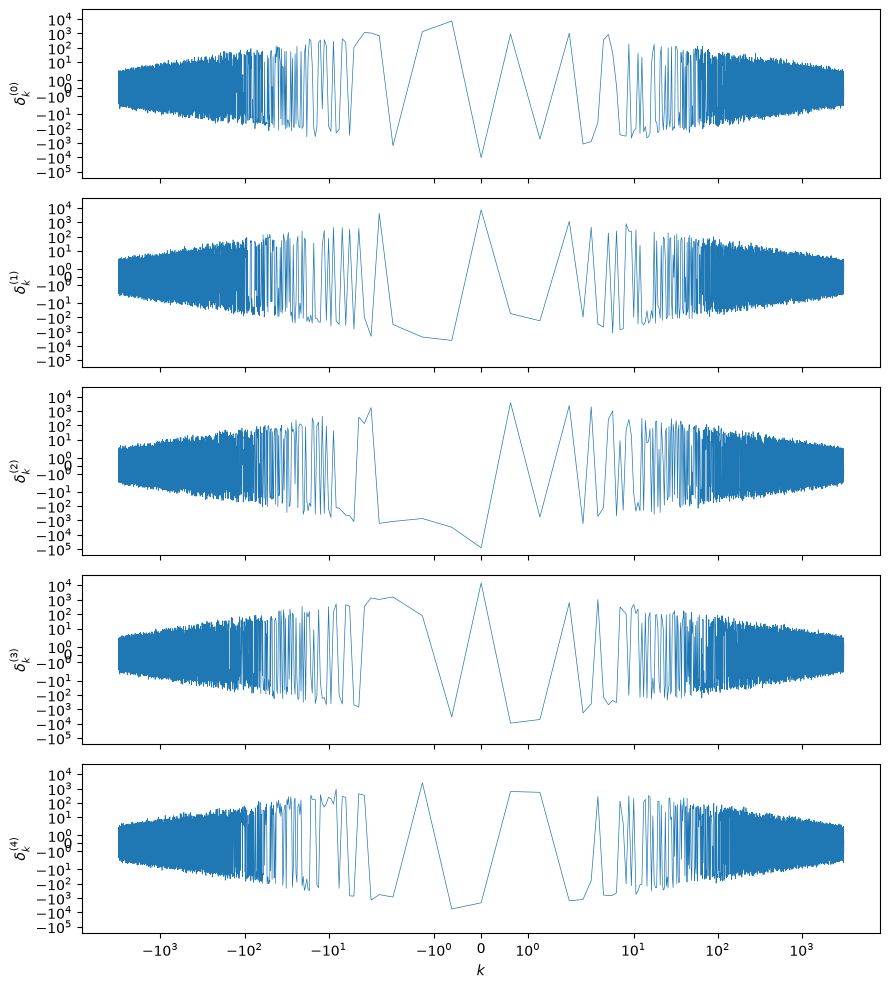

In [3]:
fig, axs = plt.subplots(5, 1, figsize=(9, 10), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    ax.plot(fourier_space, delta_k[i], lw=0.5)
    ax.set_ylabel(rf'$\delta_k^{{({i})}}$')
axs[-1].set_xscale('symlog')
axs[-1].set_yscale('symlog')
axs[-1].set_xlabel('$k$')
plt.tight_layout()
plt.show()

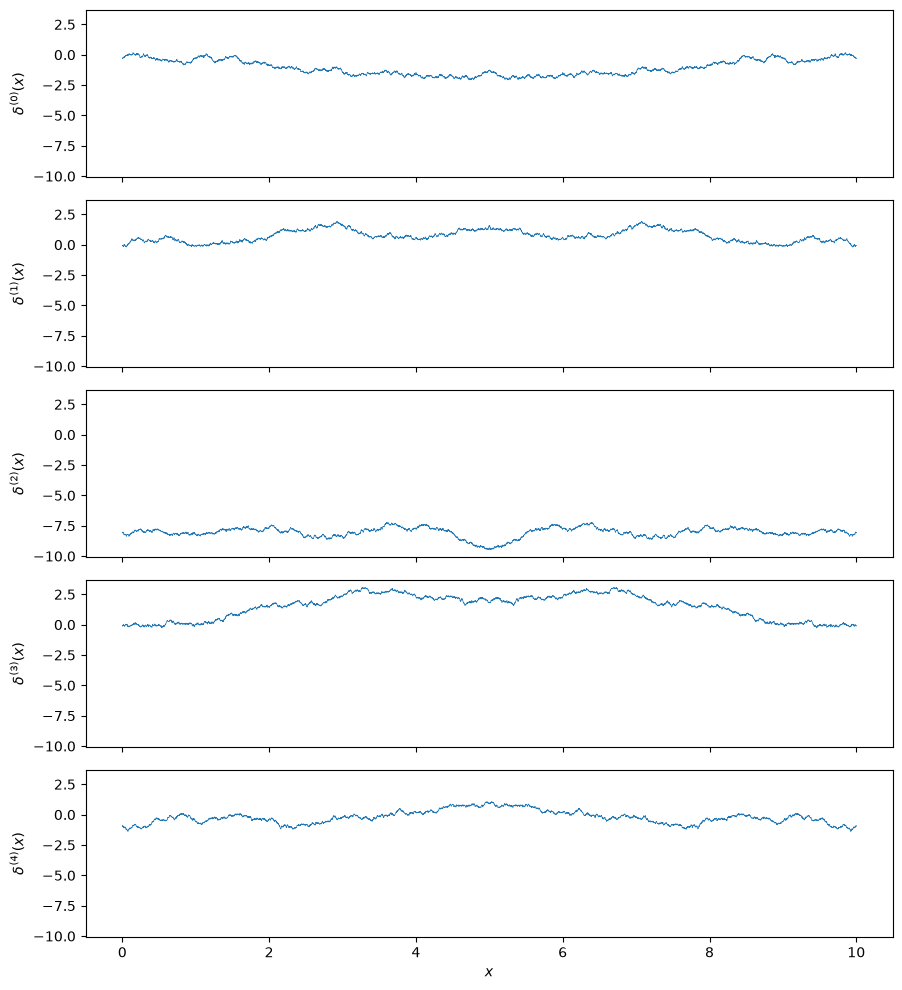

In [ ]:
fig, axs = plt.subplots(5, 1, figsize=(9, 10), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    ax.set_ylabel(rf'$\delta^{{({i})}}(x)$')
axs[-1].set_xlabel('$x$')
plt.tight_layout()
plt.show()

1. Sí, las realizaciones son diferentes.
2. Sí, todas parecen venir del mismo mecanismo: todas las realizaciones tienen la misma forma de "ruido plano" a lo largo de todo el intervalo.
3. Las amplitudes relativas parecen siempre las mismas, aunque las amplitudes globales no son claramente las mismas. También, todas parecen mantener la forma plana sin explitar en algún punto en contreto.

## 2. What condition makes the field real?

In [5]:
mask = fourier_space < 0
rng_childs = rng.spawn(5) # New childs
for i in range(5):
    delta_k[i, mask] = rng_childs[i].normal(0, np.sqrt(N**2 * Pk[mask] / L))
delta_x = np.fft.ifft(np.fft.ifftshift(delta_k, axes=1), axis=1)

/home/jairf/miniconda3/envs/cosmo/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jairf/miniconda3/envs/cosmo/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


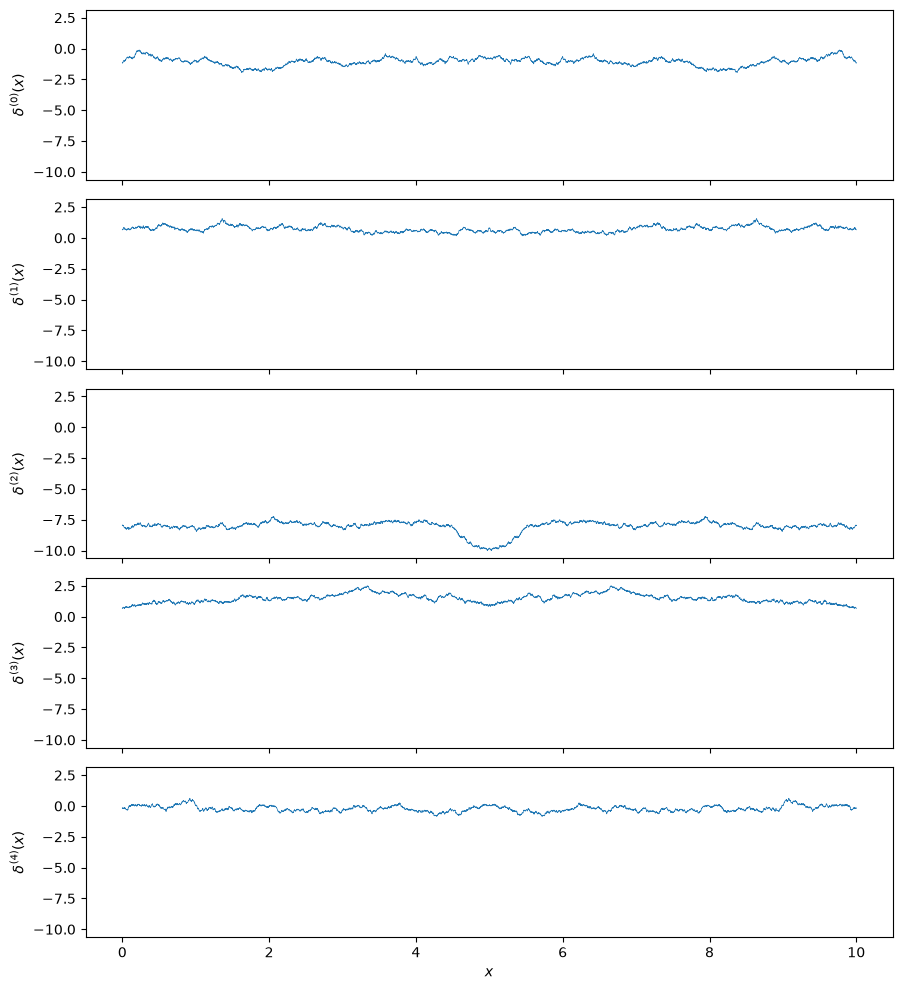

In [6]:
fig, axs = plt.subplots(5, 1, figsize=(9, 10), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    ax.plot(real_space, delta_x[i], lw=0.5)
    ax.set_ylabel(rf'$\delta^{{({i})}}(x)$')
axs[-1].set_xlabel('$x$')
plt.tight_layout()
plt.show()